#Simple Audio exercise with Transformer
Generated with the assistance of ChatGPT and the simple_audio exercise.

Using mini speech commands dataset, which was used previously in the simple_audio.ipynb exercise.


#Importing the needed libraries

In [67]:
import os
import pathlib
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

#Loading the dataset (mini speech commands dataset)

In [68]:
# =========================
# 1. Load Dataset
# =========================

"""DATASET_URL = "http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"
data_dir = tf.keras.utils.get_file(
    'mini_speech_commands',
    origin=DATASET_URL,
    extract=True,
    cache_dir='.', cache_subdir='data'
)

data_dir = pathlib.Path(data_dir)

# Remove "README" if exists
if (data_dir / "README.md").exists():
    os.remove(data_dir / "README.md")"""

DATASET_PATH = 'data/mini_speech_commands_extracted/mini_speech_commands'

data_dir = pathlib.Path(DATASET_PATH)
if not data_dir.exists():
  tf.keras.utils.get_file(
      'mini_speech_commands.zip',
      origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
      extract=True,
      cache_dir='.', cache_subdir='data')

commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands = commands[(commands != 'README.md') & (commands != '.DS_Store')]
print('Commands:', commands)


Commands: ['go' 'no' 'up' 'down' 'yes' 'stop' 'left' 'right']


#Creating the Training and Validation data sets

In [69]:
# =========================
# 2. Create Train/Val Sets
# =========================

"""batch_size = 64
seed = 42

train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=batch_size,
    validation_split=0.2,
    seed=seed,
    output_sequence_length=16000,
    subset='both'
)

label_names = np.array(train_ds.class_names)
print("Labels:", label_names)"""


# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='both')

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)

Found 8000 files belonging to 8 classes.
Using 6400 files for training.
Using 1600 files for validation.

label names: ['down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']


#Drop extra axis from audio

In [70]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

#Making test and Validation data

In [71]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 16000)
(64,)


#Creating a Spectogram function


In [72]:
# =========================
# 3. Spectrogram Function
# =========================

def get_spectrogram(waveform):
    spectrogram = tf.signal.stft(
        waveform,
        frame_length=255,
        frame_step=128
    )
    spectrogram = tf.abs(spectrogram)
    spectrogram = spectrogram[..., tf.newaxis]
    return spectrogram



#Create spectogram datasets

In [73]:
def make_spec_ds(ds):
    return ds.map(
        lambda audio, label: (get_spectrogram(audio), label),
        num_parallel_calls=tf.data.AUTOTUNE
    )

train_ds = make_spec_ds(train_ds)
val_ds = make_spec_ds(val_ds)
test_ds = make_spec_ds(test_ds)

In [74]:
train_ds = train_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

In [75]:
for example_spectrograms, example_spect_labels in train_ds.take(1):
  break

#Making the Transformer Components

In [76]:
# =========================
# 4. Transformer Components
# =========================

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, embed_dim):
        super().__init__()
        self.pos_emb = self.add_weight(
            shape=(sequence_length, embed_dim),
            initializer="random_normal"
        )

    def call(self, x):
        return x + self.pos_emb


def transformer_block(x, embed_dim, num_heads, ff_dim):
    attn = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim
    )(x, x)

    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(embed_dim)(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x

#Building the Transformer model

In [77]:
"""# =========================
# 5. Build Transformer Model
# =========================

def build_transformer(input_shape, num_classes):
    freq, time, _ = input_shape

    inputs = layers.Input(shape=input_shape)

    # Remove channel dim
    x = layers.Reshape((freq, time))(inputs)

    # Treat time as sequence → (time, freq)
    x = layers.Permute((2, 1))(x)

    # Linear embedding
    embed_dim = 128
    x = layers.Dense(embed_dim)(x)

    # Positional encoding
    x = PositionalEmbedding(sequence_length=x.shape[1], embed_dim=embed_dim)(x)

    # Transformer blocks
    for _ in range(2):
        x = transformer_block(x, embed_dim, num_heads=4, ff_dim=256)

    # Pooling
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)"""

def build_transformer(input_shape, num_classes):
  time, freq, _ = input_shape

  inputs = layers.Input(shape=input_shape)

  # Remove channel dimension
  x = layers.Reshape((time, freq))(inputs)

  # Treat time as sequence
  embed_dim = 128
  x = layers.Dense(embed_dim)(x)

  # Positional encoding
  x = PositionalEmbedding(sequence_length=time, embed_dim=embed_dim)(x)

  # Transformer layers
  for _ in range(2):
      x = transformer_block(x, embed_dim, num_heads=4, ff_dim=256)

  # Pooling
  x = layers.GlobalAveragePooling1D()(x)

  x = layers.Dense(128, activation="relu")(x)
  outputs = layers.Dense(num_classes, activation="softmax")(x)

  return models.Model(inputs, outputs)

#Compile and Train the Transformer model

In [78]:
# =========================
# 6. Compile & Train
# =========================
input_shape = example_spectrograms.shape[1:]
num_labels = len(label_names)

model = build_transformer(input_shape, num_labels)

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 124, 129,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 124, 129)  │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 124, 128)  │     16,640 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 124, 128)  │     15,872 │ dense_20[0][0]    │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 124, 128)  │    263,808 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 124, 128)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 124, 128)  │        256 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 124, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 124, 128)  │     32,896 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 124, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 124, 128)  │        256 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 124, 128)  │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 124, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 124, 128)  │        256 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 124, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 124, 128)  │     32,896 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 124, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 124, 128)  │        256 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat

 Total params: 710,536 (2.71 MB)

 Trainable params: 710,536 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.4823 - loss: 1.4065 - val_accuracy: 0.6745 - val_loss: 0.9581
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7194 - loss: 0.8064 - val_accuracy: 0.8034 - val_loss: 0.6225
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7994 - loss: 0.5989 - val_accuracy: 0.8073 - val_loss: 0.6123
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8356 - loss: 0.4856 - val_accuracy: 0.8216 - val_loss: 0.5524
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8691 - loss: 0.3927 - val_accuracy: 0.8503 - val_loss: 0.4674
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8925 - loss: 0.3291 - val_accuracy: 0.8424 - val_loss: 0.4705
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8947 - loss: 0.3027 - val_accuracy: 0.8594 - val_loss: 0.4817
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8942 - loss: 0.2956 - val_acc

#Evaluation of model

In [79]:
# =========================
# 7. Evaluate
# =========================

test_loss, test_acc = model.evaluate(val_ds)
print("Validation accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8646 - loss: 0.4981
Validation accuracy: 0.8645833134651184


#Plotting the training and validation loss curves

Text(0, 0.5, 'Accuracy [%]')

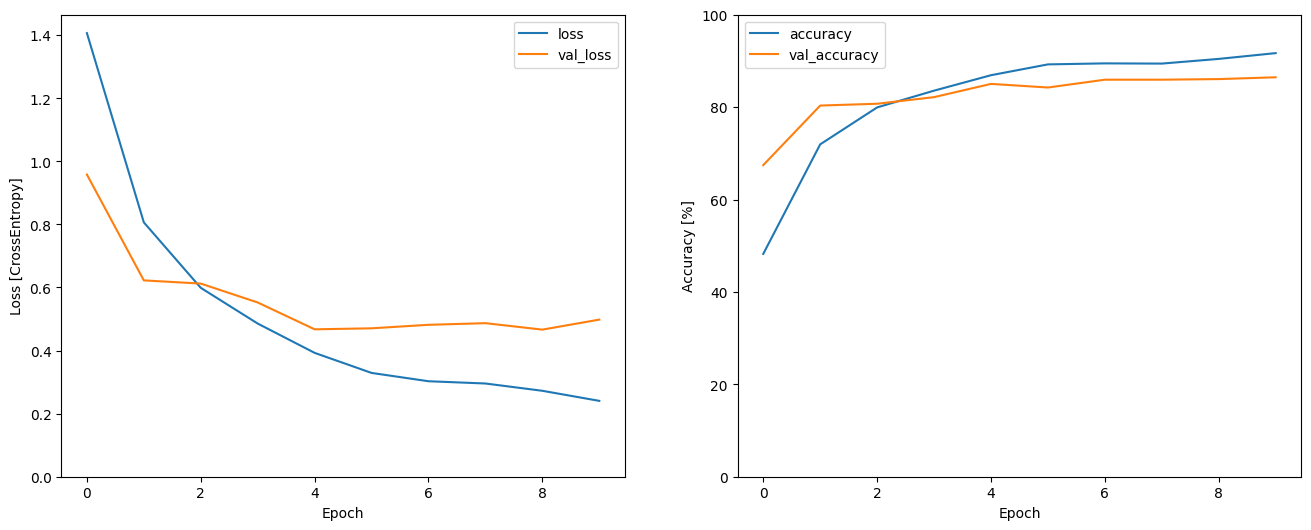

In [80]:
import matplotlib.pyplot as plt

metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')